In [1]:
# تثبيت مكتبة Ultralytics الخاصة بنماذج YOLO
!pip install ultralytics

# تثبيت مكتبة Roboflow لتحميل البيانات بسهولة
!pip install roboflow

import os
from ultralytics import YOLO
from roboflow import Roboflow


In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="5WeTwjJ0F7By45093WJO")
project = rf.workspace("traffic").project("traffic-dataset-z21ak")
version = project.version(1)
dataset = version.download("yolov8")
DATA_YAML_PATH = os.path.join(dataset.location, "data.yaml")
print("Dataset downloaded to:", dataset.location)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Traffic-Dataset-1 in yolov8:: 100%|██████████| 86/86 [00:00<00:00, 10093.75it/s]

Dataset downloaded to: /content/Traffic-Dataset-1


In [8]:
# استدعاء نموذج YOLOv8 المسبق التدريب (الحجم الصغير مناسب وسريع للتدريب)
model = YOLO("yolov8s.pt")

# بدء عملية التدريب لمدة 50 دورة (Epochs) وحجم حزمة 16
# يمكنك زيادة الـ epochs إلى 100 لنتائج أفضل إذا سمح الوقت
results = model.train(
    data=DATA_YAML_PATH,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0, # استخدام الـ GPU
    name='traffic_management_yolov8'
)


Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Traffic-Dataset-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_management_yolov8, nbs=64, nms=


image 1/1 /content/Traffic-Dataset-1/test/images/srirat-02-20210811-170944-raining-cut_mp4-24_jpg.rf.0b15b666102163273ce50967a5e8fb25.jpg: 640x640 3 cars, 16.1ms
Speed: 2.4ms preprocess, 16.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


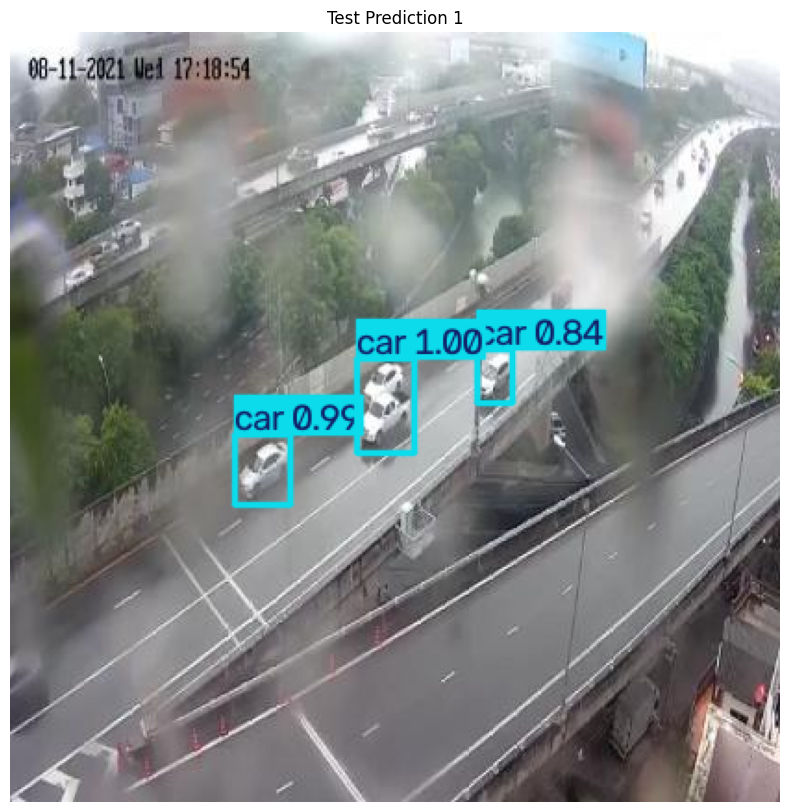


image 1/1 /content/Traffic-Dataset-1/test/images/srirat-02-20210811-170944-raining-cut_mp4-26_jpg.rf.9a0a31cd5b646ca0733c07adcd9ba9ac.jpg: 640x640 4 cars, 1 motorcycle, 16.2ms
Speed: 2.4ms preprocess, 16.2ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


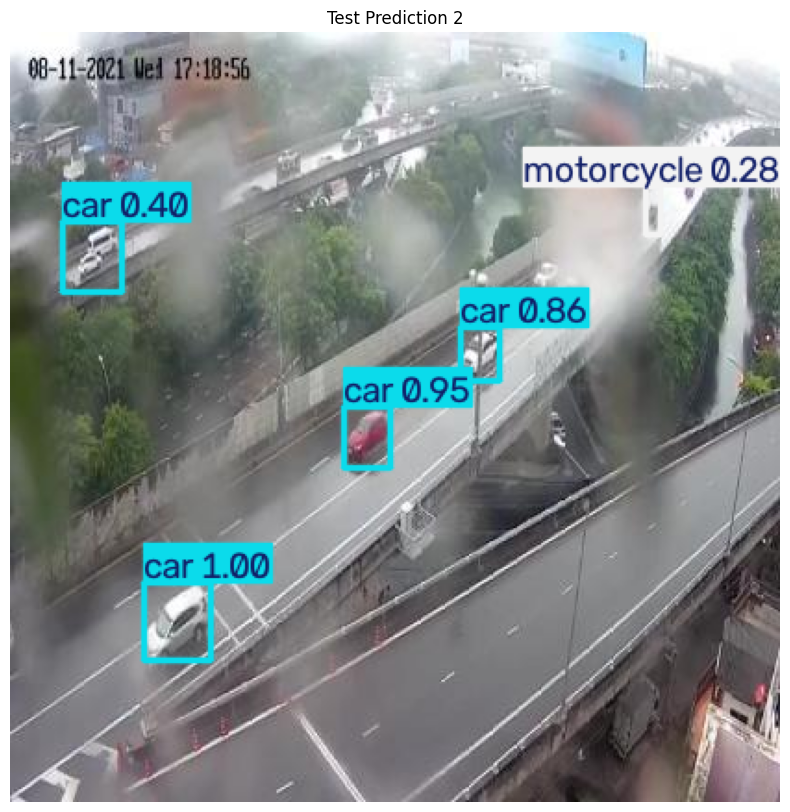


image 1/1 /content/Traffic-Dataset-1/test/images/hlp-01-20210610-205037-cut_mp4-52_jpg.rf.62d4a080b0ebaea74bf21df00f0801ff.jpg: 640x640 5 cars, 1 motorcycle, 16.2ms
Speed: 2.3ms preprocess, 16.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


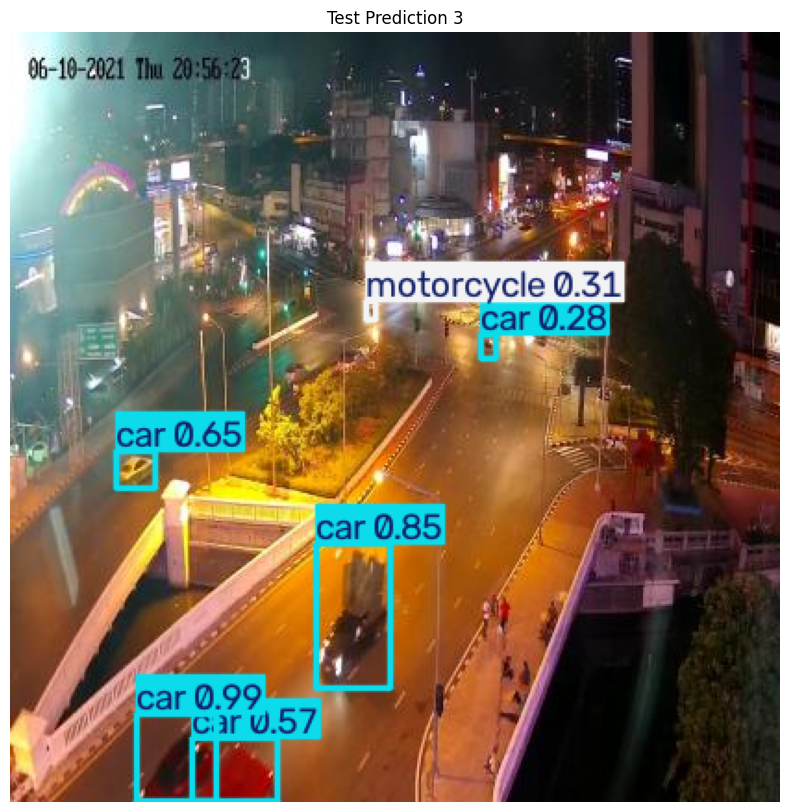


image 1/1 /content/Traffic-Dataset-1/test/images/hlp-01-20210610-205037-cut_mp4-30_jpg.rf.453d8b5190c1d8f74a7048e82b079907.jpg: 640x640 2 buss, 13 cars, 1 motorcycle, 17.4ms
Speed: 5.3ms preprocess, 17.4ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


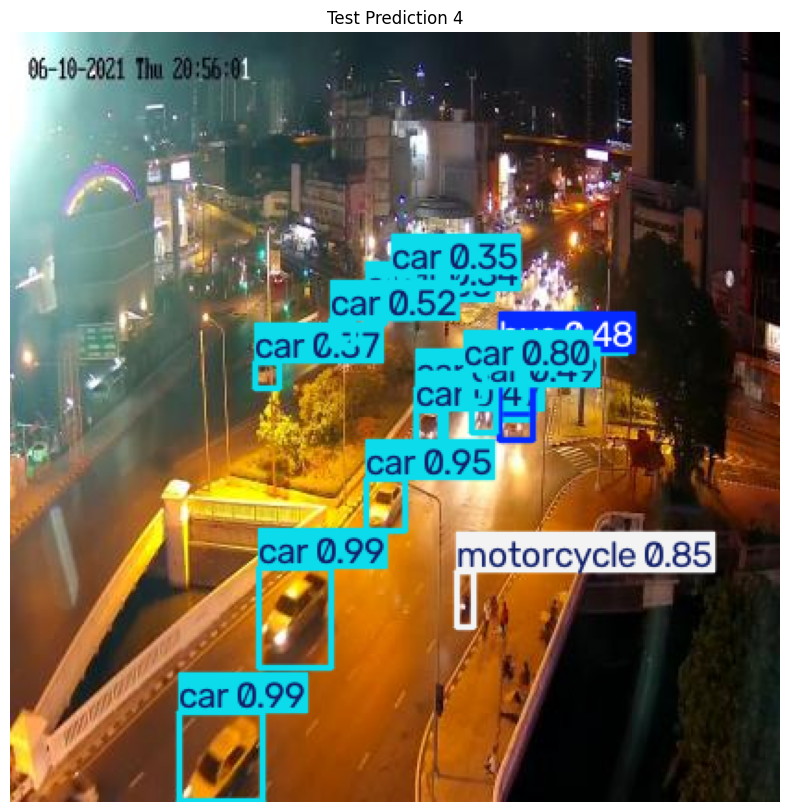


image 1/1 /content/Traffic-Dataset-1/test/images/srirat-02-20210811-170944-raining-cut_mp4-42_jpg.rf.0b03826e5349e11b57aa0f65a4270eba.jpg: 640x640 3 cars, 16.2ms
Speed: 2.4ms preprocess, 16.2ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


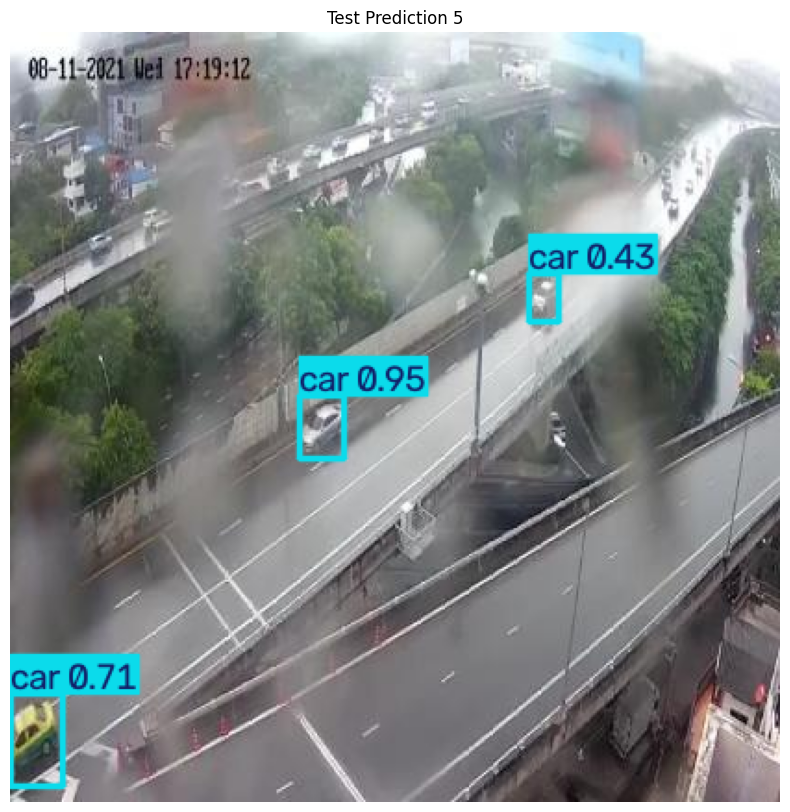

In [9]:
import matplotlib.pyplot as plt
import cv2
import glob

# 1. تحميل النموذج الأفضل الذي تم تدريبه
best_model_path = 'runs/detect/traffic_management_yolov8/weights/best.pt'
model = YOLO(best_model_path)

# 2. الحصول على مسارات صور الاختبار الفعلي
# تأكد من مطابقة مسار مجلد الـ test بناءً على المسار المطبوع عند تحميل البيانات
test_images = glob.glob(f"{dataset.location}/test/images/*.jpg")

# 3. تشغيل التنبؤ على أول 5 صور وعرضها برمجياً
for i, img_path in enumerate(test_images[:5]):
    results = model.predict(source=img_path, conf=0.25)

    # رسم الصناديق على الصورة
    res_plotted = results[0].plot()

    # عرض الصورة باستخدام Matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.title(f"Test Prediction {i+1}")
    plt.axis('off')
    plt.show()


In [10]:
# كود حساب عدد المركبات لكل فئة في صورة اختبارية
test_img = test_images[0] # اختر أي صورة تريدها
results = model.predict(source=test_img, conf=0.25)

# استخراج الكائنات المكتشفة وأسمائها
detected_classes = results[0].boxes.cls.cpu().numpy()
names = model.names

# حساب التكرار لكل فئة
counts = {}
for clsid in detected_classes:
    class_name = names[int(clsid)]
    counts[class_name] = counts.get(class_name, 0) + 1

# طباعة تقرير الكثافة المرورية
print("=== تقرير الكثافة المرورية عند التقاطع ===")
for vehicle_type, count in counts.items():
    print(f"🚗 {vehicle_type}: {count}")



image 1/1 /content/Traffic-Dataset-1/test/images/srirat-02-20210811-170944-raining-cut_mp4-24_jpg.rf.0b15b666102163273ce50967a5e8fb25.jpg: 640x640 3 cars, 16.2ms
Speed: 2.8ms preprocess, 16.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
=== تقرير الكثافة المرورية عند التقاطع ===
🚗 car: 3
